# PoD_esti v03 —— 探测概率估计（全噪声档扫描 + 窗长对比）

> v03 基于 v02 的已验证引擎，新增：
> 1. 噪声网格细化（步长 0.25），N_shots=4 延伸到 noise=30，N_shots=1 到 noise=12
> 2. 窗长对比：由 152-bin MC 结果外推 50/152/2048 bin 窗的阈值（零额外 MC）
> 3. **全部噪声档的 PoD**：probit 拟合 → boost@PoD50 / boost@PoD90 vs noise 主交付图

## 缩写
- **SPAD** (Single-Photon Avalanche Diode)，**PDE** (Photon Detection Efficiency)
- **ToF** (Time of Flight)，**FAR** (False Alarm Rate)，**PoD** (Probability of Detection)
- **MC** (Monte Carlo)，**ppm** (parts per million)，**IRF** (Instrument Response Function)


## 模块 0 — 参数与常数

In [2]:
import json, os, time, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.stats import binom as _binom, norm as _norm

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

C_LIGHT  = 2.99792458e8
H_PLANCK = 6.62607015e-34

PARAMS = {
    "laser": {"wavelength": 905e-9, "amp_mode": "peak", "P_peak": 235.0,
               "E_pulse": 800e-9, "tau_r": 0.7e-9, "tau_f": 1.9e-9,
               "x_L": 60e-6, "y_L": 1150e-6},
    "tx": {"f_TX": 36e-3, "D_TX": 12.7e-3, "eta_coupling": 0.87, "T_TX": 0.92},
    "channel": {"alpha": 0.1e-3},
    "rx": {"f_RX": 25e-3, "D_RX": 13e-3, "eta_RX": 0.82,
           "T_RX": 0.90, "T_filter": 0.90, "filter_bw": 12e-9},
    "spad": {"PDE": 0.30, "DCR": 0.0e3, "jitter_sigma": 100e-12,
              "tau_rc": 8.7315e-9, "Vov_max": 3.3, "Vth_frac": 0.60,
              "reset_mode": "count", "resp_shape": "exp", "resp_k": 3.0},
    "spad_array": {"pitch": 10e-6, "Nx": 9, "Ny": 120, "fill_factor": 1.00},
    "ambient": {"enable": True, "E_lambda": 0.68, "surface_rho": 0.10},
    "hist": {"bin_width": 1e-9, "seed": 0},
}
E_PHOTON = H_PLANCK * C_LIGHT / PARAMS["laser"]["wavelength"]

# ---- PoD_esti 专用参数（v03 已改的用 ★ 标注）----
D_TARGET   = 15.0
RHO_TARGET = 0.10
WIN_LO_NS  = 0.0
WIN_HI_NS  = 200.0
TRIM_NS    = 24.0
WARM_NS    = 50.0
DT_FINE    = 200e-12
MACRO_BX   = 9
MACRO_BY   = 3
N_SHOTS_LIST = [1, 4]

# ★ v03：更宽的噪声网格，步长 0.25
NOISE_GRID = {
    1: np.round(np.arange(0.25, 12.0  + 1e-9, 0.25), 4),   # 48 档，上限 n_tr=27
    4: np.round(np.arange(0.25, 30.0  + 1e-9, 0.25), 4),   # 120 档，上限 n_tr=108
}

TARGET_FARS   = [100e-6, 10e-6]
# ★ v03：N_MC=3e5（100 ppm 约 30 事件，可靠；10 ppm 约 3 事件，趋势参考）
N_MC_NOISE    = 300_000
MC_CHUNK      = 25_000

# ★ v03：窗长对比（等效分析 bin 数，参考窗 = 统计窗 N_STAT 由掐头去尾决定）
WIN_CMP_BINS  = [50, 152, 2048]

# ★ v03：全档 PoD（probit 拟合）
N_POD_EVAL    = 12     # 每档能量评估次数（固定 log 区间 [1e-6, 1e2]）
N_MC_POD      = 500    # 每次评估的 MC 条数（PoD 误差 ±4.5%，足够 probit 拟合）
SIG_PRE_NS    = 3.0
SIG_POST_NS   = 12.0
POD_WARM_NS   = 60.0

USE_CACHE     = True
CACHE_NOISE   = "pod_esti_v03_cache_noise.npz"
CACHE_POD     = "pod_esti_v03_cache_pod.npz"

print(f"单光子能量 E_photon = {E_PHOTON:.3e} J")
print(f"目标 D = {D_TARGET} m → ToF = {2*D_TARGET/C_LIGHT*1e9:.2f} ns")
for ns_, g_ in NOISE_GRID.items():
    print(f"  ★ N_shots={ns_}: noise {g_[0]:g}→{g_[-1]:g} 步长 {g_[1]-g_[0]:g}，共 {g_.size} 档")
print(f"★ N_MC_NOISE = {N_MC_NOISE:,}（100ppm：~{int(N_MC_NOISE*100e-6)} 事件/档，"
      f"10ppm：~{int(N_MC_NOISE*10e-6)} 事件/档）")
print(f"★ 窗长对比：{WIN_CMP_BINS} bins（参考窗 = 统计窗后确定）")


单光子能量 E_photon = 2.195e-19 J
目标 D = 15.0 m → ToF = 100.07 ns
  ★ N_shots=1: noise 0.25→12 步长 0.25，共 48 档
  ★ N_shots=4: noise 0.25→30 步长 0.25，共 120 档
★ N_MC_NOISE = 300,000（100ppm：~30 事件/档，10ppm：~3 事件/档）
★ 窗长对比：[50, 152, 2048] bins（参考窗 = 统计窗后确定）


## 模块 1 — 光链路（与 v02 完全一致）

In [3]:
def _pulse_norm(p=PARAMS):
    tr, tf_ = p["laser"]["tau_r"], p["laser"]["tau_f"]
    t_peak = np.log(tf_ / tr) / (1.0/tr - 1.0/tf_)
    s_peak = np.exp(-t_peak/tf_) - np.exp(-t_peak/tr)
    A = (p["laser"]["E_pulse"]*s_peak/(tf_-tr)
         if p["laser"]["amp_mode"]=="energy" else p["laser"]["P_peak"])
    return A, s_peak, t_peak, tf_-tr

def pulse_temporal(t, p=PARAMS):
    tr, tf_ = p["laser"]["tau_r"], p["laser"]["tau_f"]
    A, s_peak, _, _ = _pulse_norm(p)
    tpos = np.clip(t, 0.0, None)
    return A * np.clip(np.where(t>=0, np.exp(-tpos/tf_)-np.exp(-tpos/tr), 0.0), 0, None)/s_peak

def pulse_energy(p=PARAMS):
    A, s_peak, _, area = _pulse_norm(p); return A/s_peak*area

def tx_derived(p=PARAMS):
    xL, yL = p["laser"]["x_L"], p["laser"]["y_L"]
    fT, lam, w0 = p["tx"]["f_TX"], p["laser"]["wavelength"], p["tx"]["D_TX"]/2
    tgx, tgy, tdf = xL/(2*fT), yL/(2*fT), lam/(np.pi*w0)
    tx_ = np.hypot(tgx,tdf); ty_ = np.hypot(tgy,tdf)
    return {"theta_x":tx_,"theta_y":ty_,"zR_x":w0/tx_,"zR_y":w0/ty_,"w0":w0,
            "eta_TX":p["tx"]["eta_coupling"]*p["tx"]["T_TX"]}

def atm_transmission(D, p=PARAMS): return np.exp(-p["channel"]["alpha"]*D)
def rx_area(p=PARAMS): return np.pi*(p["rx"]["D_RX"]/2)**2

def beam_spot_size(D, p=PARAMS):
    tx=tx_derived(p); w0=tx["w0"]
    return (2*w0*np.sqrt(1+(D/tx["zR_x"])**2), 2*w0*np.sqrt(1+(D/tx["zR_y"])**2))

def time_of_flight(D): return 2.0*D/C_LIGHT

def rx_image_spot_size(D, p=PARAMS):
    xD, yD = beam_spot_size(D, p)
    sa = 2.44*p["laser"]["wavelength"]*(p["rx"]["f_RX"]/p["rx"]["D_RX"])
    return np.hypot(xD/D*p["rx"]["f_RX"],sa), np.hypot(yD/D*p["rx"]["f_RX"],sa)

def link_factor(echo, p=PARAMS):
    tx=tx_derived(p); D=echo["D"]
    Omega=rx_area(p)/D**2
    eta_rx=p["rx"]["eta_RX"]*p["rx"]["T_RX"]*p["rx"]["T_filter"]
    return (tx["eta_TX"]*echo["frac"]*(echo["rho"]/np.pi)*Omega
            *atm_transmission(D,p)**2*eta_rx)

def gaussian_kernel(sigma, dt, n_sigma=5):
    if sigma<=0: return np.array([1.0/dt])
    half=max(1,int(np.ceil(n_sigma*sigma/dt)))
    tk=np.arange(-half,half+1)*dt; k=np.exp(-0.5*(tk/sigma)**2)
    return k/(k.sum()*dt)

def pixel_collection_matrix(D, p=PARAMS):
    sx, sy = rx_image_spot_size(D, p)
    sig_x, sig_y = sx/4, sy/4
    xi = (np.arange(p["spad_array"]["Nx"])-(p["spad_array"]["Nx"]-1)/2)*p["spad_array"]["pitch"]
    yj = (np.arange(p["spad_array"]["Ny"])-(p["spad_array"]["Ny"]-1)/2)*p["spad_array"]["pitch"]
    pitch = p["spad_array"]["pitch"]
    def _fr(c, s): return 0.5*(erf((c+pitch/2)/(np.sqrt(2)*s))-erf((c-pitch/2)/(np.sqrt(2)*s)))
    return np.outer(_fr(xi,sig_x),_fr(yj,sig_y)), _fr(xi,sig_x), _fr(yj,sig_y)

def ambient_photon_rate_per_pixel(p=PARAMS, e_lambda=None):
    if not p["ambient"]["enable"]: return 0.0
    El = (p["ambient"]["E_lambda"] if e_lambda is None else e_lambda)
    E = El*(p["rx"]["filter_bw"]*1e9)
    L = p["ambient"]["surface_rho"]*E/np.pi
    iFOV = p["spad_array"]["pitch"]/p["rx"]["f_RX"]
    return L*iFOV**2*rx_area(p)/E_PHOTON*p["rx"]["T_RX"]*p["rx"]["T_filter"]

def signal_photon_rate_fine(echo, f_pix_ij, tf_grid, p=PARAMS):
    t0=time_of_flight(echo["D"])
    r=(pulse_temporal(tf_grid-t0,p)*link_factor(echo,p)/E_PHOTON*f_pix_ij)
    sig_b=echo.get("tilt_deg",0.0)
    if sig_b>0:
        dt=tf_grid[1]-tf_grid[0]
        r=np.convolve(r,gaussian_kernel(sig_b,dt),mode="same")*dt
    return r

ECHO0 = {"D": D_TARGET, "rho": RHO_TARGET, "frac": 1.00, "tilt_deg": 0.0}
E_PULSE_BASE = pulse_energy()
_sx, _sy = rx_image_spot_size(D_TARGET)
print(f"E_pulse_base = {E_PULSE_BASE*1e9:.1f} nJ，链路因子 = {link_factor(ECHO0):.3e}")
print(f"像面光斑 x={_sx*1e6:.2f} µm, y={_sy*1e6:.2f} µm")


E_pulse_base = 799.4 nJ，链路因子 = 9.953e-09
像面光斑 x=46.98 µm, y=798.91 µm


## 模块 2 — 时间窗与宏像元（与 v02 完全一致）

In [4]:
_sp = PARAMS["spad"]
PDE        = _sp["PDE"]
JIT        = _sp["jitter_sigma"]
TAU_RC     = _sp["tau_rc"]
VTH_FRAC   = _sp["Vth_frac"]
RESP_SHAPE = _sp["resp_shape"]
RESP_K     = _sp["resp_k"]
jit        = JIT

T_OVER = -TAU_RC * np.log(1.0 - VTH_FRAC)

BIN_W   = PARAMS["hist"]["bin_width"]
WIN_LO  = WIN_LO_NS * 1e-9; WIN_HI = WIN_HI_NS * 1e-9
NBINS   = int(round((WIN_HI - WIN_LO) / BIN_W))
CENTERS = WIN_LO + (np.arange(NBINS) + 0.5) * BIN_W
TC_NS   = CENTERS * 1e9

_keep   = (TC_NS >= TRIM_NS) & (TC_NS <= WIN_HI_NS - TRIM_NS)
IDX_STAT= np.where(_keep)[0]
I_STAT0, I_STAT1 = int(IDX_STAT[0]), int(IDX_STAT[-1]+1)
N_STAT  = I_STAT1 - I_STAT0

TF_GEN  = np.arange(WIN_LO - WARM_NS*1e-9, WIN_HI, DT_FINE)

N_PIX_MACRO = MACRO_BX * MACRO_BY
FPIX, FX, FY = pixel_collection_matrix(D_TARGET)
_n_macro = PARAMS["spad_array"]["Ny"] // MACRO_BY
_macro_fsum = np.array([FPIX[:, m*MACRO_BY:(m+1)*MACRO_BY].sum() for m in range(_n_macro)])
M_PEAK  = int(_macro_fsum.argmax())
F_VALS  = FPIX[:, M_PEAK*MACRO_BY:(M_PEAK+1)*MACRO_BY].ravel()

R_AMB_BASE = ambient_photon_rate_per_pixel()
T0_SIG     = time_of_flight(D_TARGET)
T0_SIG_NS  = T0_SIG * 1e9
R_SIG_UNIT_GEN = signal_photon_rate_fine(ECHO0, 1.0, TF_GEN)

print(f"T_OVER = {T_OVER*1e9:.3f} ns，采集窗 {WIN_LO_NS:.0f}–{WIN_HI_NS:.0f} ns → {NBINS} bins")
print(f"统计窗（掐头去尾 {TRIM_NS:.0f} ns）→ [{I_STAT0}, {I_STAT1}) 共 {N_STAT} bins")
print(f"宏像元 {MACRO_BX}×{MACRO_BY} = {N_PIX_MACRO} SPAD，参考统计窗 N_STAT = {N_STAT} bins")
for ns_ in N_SHOTS_LIST:
    print(f"  N_shots={ns_} → n_tr={N_PIX_MACRO*ns_}，二值硬上限 macro_cap={N_PIX_MACRO*ns_}")


T_OVER = 8.001 ns，采集窗 0–200 ns → 200 bins
统计窗（掐头去尾 24 ns）→ [24, 176) 共 152 bins
宏像元 9×3 = 27 SPAD，参考统计窗 N_STAT = 152 bins
  N_shots=1 → n_tr=27，二值硬上限 macro_cap=27
  N_shots=4 → n_tr=108，二值硬上限 macro_cap=108


## 模块 3 — SPAD 二值采样引擎（与 v02 完全一致）

In [5]:
def spad_response_g(vov_frac, shape="linear", k=3.0):
    x = np.clip(vov_frac, 0.0, 1.0)
    return (1.0 - np.exp(-k*x)) / (1.0 - np.exp(-k)) if shape == "exp" else x

U_C    = 20.0 * TAU_RC
E_MAX  = 30.0
N_ETAB = 262144

def build_renewal_table(r_det, tau_rc=TAU_RC, resp_shape=RESP_SHAPE, resp_k=RESP_K,
                        d_max=None, n_grid=400001):
    if d_max is None: d_max = E_MAX/r_det + 40*tau_rc
    d = np.linspace(0.0, d_max, n_grid)
    h = r_det * spad_response_g(1.0 - np.exp(-d/tau_rc), resp_shape, resp_k)
    H = np.concatenate([[0.0], np.cumsum(0.5*(h[1:]+h[:-1])*np.diff(d))])
    return d, H

def p_bin_equilibrium(r_det, t_over=T_OVER, tau_rc=TAU_RC,
                      resp_shape=RESP_SHAPE, resp_k=RESP_K, n=200001):
    d = np.linspace(0.0, U_C, n)
    h = r_det * spad_response_g(1.0 - np.exp(-d/tau_rc), resp_shape, resp_k)
    H = np.concatenate([[0.0], np.cumsum(0.5*(h[1:]+h[:-1])*np.diff(d))])
    S = np.exp(-H); mu = np.trapezoid(S, d) + S[-1]/r_det
    m = d <= t_over
    return float(np.trapezoid(S[m], d[m]) / mu), float(mu)

def r_det_for_noise(noise_target, n_tr, lo=1e2, hi=1e11, iters=45):
    p_t = noise_target / n_tr
    if not (0.0 < p_t < 1.0): return np.nan
    for _ in range(iters):
        mid = np.sqrt(lo*hi)
        if p_bin_equilibrium(mid, n=20001)[0] < p_t: lo = mid
        else: hi = mid
    return float(np.sqrt(lo*hi))

def e_lambda_for_r_det(r_det, p=PARAMS):
    return p["ambient"]["E_lambda"] * (r_det/PDE) / R_AMB_BASE

def build_inv_table(r_det, tau_rc=TAU_RC, resp_shape=RESP_SHAPE, resp_k=RESP_K,
                    e_max=E_MAX, n_etab=N_ETAB):
    d, H = build_renewal_table(r_det, tau_rc, resp_shape, resp_k)
    e_grid = np.linspace(0.0, e_max, n_etab)
    inv = np.interp(e_grid, H, d).astype(np.float32)
    return inv, np.float32((n_etab-1)/e_max)

def noise_macro_hist_fast(n_real, n_tr, r_det, rng, win_lo=None, win_hi=None,
                          nbins=None, bin_w=None, t_over=T_OVER, jitter=JIT,
                          warm=None, max_round=20000, inv_tab=None):
    win_lo = WIN_LO if win_lo is None else win_lo
    win_hi = WIN_HI if win_hi is None else win_hi
    nbins  = NBINS  if nbins  is None else nbins
    bin_w  = BIN_W  if bin_w  is None else bin_w
    warm   = WARM_NS*1e-9 if warm is None else warm
    if inv_tab is None: inv_tab = build_inv_table(r_det)
    inv, scale = inv_tab; n_e = inv.size
    t_start = np.float32(win_lo - warm)
    wl = np.float32(win_lo); wh = np.float32(win_hi)
    tov = np.float32(t_over); bw = np.float32(bin_w)
    D_FLOOR = np.float32(1e-13)
    N = n_real * n_tr
    ri = np.repeat(np.arange(n_real, dtype=np.int32), n_tr)
    t_j = (t_start + rng.exponential(1.0/r_det, N)).astype(np.float32)
    j_j = (rng.normal(0.0, jitter, N).astype(np.float32) if jitter>0
           else np.zeros(N, np.float32))
    lo_all, hi_all, ri_all = [], [], []
    for _ in range(max_round):
        keep = t_j < wh
        if not keep.any(): break
        t_j = t_j[keep]; j_j = j_j[keep]; ri = ri[keep]
        m_ = t_j.size
        E = rng.standard_exponential(m_, dtype=np.float32)
        x = np.minimum(E, np.float32(E_MAX)) * scale
        i0 = x.astype(np.int32); np.clip(i0, 0, n_e-2, out=i0)
        fr = x - i0
        delta = np.maximum(inv[i0]*(1.0-fr) + inv[i0+1]*fr, D_FLOOR)
        t_n = t_j + delta
        j_n = (rng.normal(0.0, jitter, m_).astype(np.float32) if jitter>0
               else np.zeros(m_, np.float32))
        lo_all.append(t_j + j_j)
        hi_all.append(np.minimum(t_j+j_j+tov, t_n+j_n))
        ri_all.append(ri.copy())
        t_j, j_j = t_n, j_n
    diff = np.zeros(n_real*(nbins+1), dtype=np.int32)
    if lo_all:
        lo_t = np.concatenate(lo_all); hi_t = np.concatenate(hi_all)
        rr = np.concatenate(ri_all).astype(np.int64)
        b_lo = np.clip(np.ceil((lo_t-wl)/bw-0.5), 0, nbins).astype(np.int64)
        b_hi = np.clip(np.ceil((hi_t-wl)/bw-0.5), 0, nbins).astype(np.int64)
        m = b_hi > b_lo
        if m.any():
            base = rr[m]*(nbins+1)
            diff = (np.bincount(base+b_lo[m], minlength=diff.size)
                    - np.bincount(base+b_hi[m], minlength=diff.size)).astype(np.int32)
    return np.cumsum(diff.reshape(n_real, nbins+1), axis=1)[:, :nbins]

def binary_macro_stepping(n_real, f_arr, r_sig_unit, tgrid, r_amb, centers, rng,
                          boost=1.0, tau_rc=TAU_RC, t_over=T_OVER, pde=PDE,
                          jitter=JIT, resp_shape=RESP_SHAPE, resp_k=RESP_K):
    dt = tgrid[1]-tgrid[0]; n_tr = f_arr.size; nb = len(centers)
    k_max = int(np.ceil(20.0*tau_rc/dt))
    phi = pde * spad_response_g(1.0-np.exp(-np.arange(k_max+1)*dt/tau_rc), resp_shape, resp_k)
    age  = np.full((n_real, n_tr), k_max, dtype=np.int32)
    tcov = np.full((n_real, n_tr), -1e30)
    hist = np.zeros((n_real, nb), dtype=np.int32)
    mu_all = (r_sig_unit[:, None]*f_arr[None, :]*boost + r_amb)*dt
    ib = 0
    for i in range(tgrid.size):
        t = tgrid[i]
        while ib < nb and centers[ib] < t:
            d = centers[ib] - tcov
            hist[:, ib] = ((d>=0)&(d<t_over)).sum(axis=1); ib += 1
        p_ = -np.expm1(-mu_all[i][None, :]*phi[age])
        fire = rng.random((n_real, n_tr)) < p_
        age = np.minimum(age+1, k_max)
        if fire.any():
            age[fire] = 1; nf = int(fire.sum())
            tcov[fire] = t + (rng.normal(0.0, jitter, nf) if jitter>0 else 0.0)
    while ib < nb:
        d = centers[ib] - tcov
        hist[:, ib] = ((d>=0)&(d<t_over)).sum(axis=1); ib += 1
    return hist

print("引擎就绪：noise_macro_hist_fast（快速 A）| binary_macro_stepping（快速 B）")
print("更新过程工具就绪：p_bin_equilibrium / r_det_for_noise / e_lambda_for_r_det")


引擎就绪：noise_macro_hist_fast（快速 A）| binary_macro_stepping（快速 B）
更新过程工具就绪：p_bin_equilibrium / r_det_for_noise / e_lambda_for_r_det


## 模块 4 — 纯噪声扫描（★ v03：步长 0.25，N_MC=300k）

噪声网格：N_shots=1 为 noise 0.25→12（48 档），N_shots=4 为 0.25→30（120 档）。

N_MC=300_000 时：
- **100 ppm 阈值**：约 30 个越阈事件，稳健可靠；
- **10 ppm 阈值**：约 3 个越阈事件，可给出趋势但单档误差可能 ±1 个计数，图中用虚线区分。

每档只存 peak 的 **bincount**（同 v02，信息无损，缓存极小）。


In [6]:
def peak_stats_from_cnt(cnt):
    v = np.arange(cnt.size, dtype=float); n = cnt.sum()
    mean = (v*cnt).sum()/n; var = (v*v*cnt).sum()/n - mean**2
    cum = np.cumsum(cnt)/n
    q = lambda p: float(np.searchsorted(cum, p))
    return dict(n=int(n), mean=mean, std=np.sqrt(max(var, 0.0)),
                p50=q(0.50), p99=q(0.99), p9999=q(0.9999), pmax=float(np.nonzero(cnt)[0].max()))

def run_noise_scan(n_shots, noise_grid, n_mc, chunk, seed0=3000, verbose_every=10):
    n_tr = N_PIX_MACRO * n_shots; ng = len(noise_grid)
    res = {"n_shots": n_shots, "n_tr": n_tr,
           "noise_target": np.asarray(noise_grid, float),
           "r_det": np.zeros(ng), "e_lambda": np.zeros(ng), "p_eq": np.zeros(ng),
           "noise_mc": np.zeros(ng), "noise_std": np.zeros(ng),
           "peak_cnt": np.zeros((ng, n_tr+2), dtype=np.int64)}
    t0 = time.time()
    for k, nt in enumerate(noise_grid):
        r = r_det_for_noise(float(nt), n_tr)
        res["r_det"][k] = r; res["e_lambda"][k] = e_lambda_for_r_det(r)
        res["p_eq"][k] = p_bin_equilibrium(r)[0]
        inv_tab = build_inv_table(r)
        s1 = s2 = 0.0
        for s in range(0, n_mc, chunk):
            m = min(chunk, n_mc-s)
            h = noise_macro_hist_fast(m, n_tr, r,
                                      np.random.default_rng(seed0+1000*k+s),
                                      inv_tab=inv_tab)
            a = h[:, I_STAT0:I_STAT1]; nz = a.mean(axis=1)
            s1 += nz.sum(); s2 += (nz*nz).sum()
            res["peak_cnt"][k] += np.bincount(a.max(axis=1), minlength=n_tr+2)
        res["noise_mc"][k] = s1/n_mc
        res["noise_std"][k] = np.sqrt(max(s2/n_mc-(s1/n_mc)**2, 0.0))
        if k==0 or k==ng-1 or (k+1)%verbose_every==0:
            el = time.time()-t0; eta = el/(k+1)*(ng-k-1)
            pk = peak_stats_from_cnt(res["peak_cnt"][k])
            print(f"  [N_shots={n_shots} {k+1:>3d}/{ng}] noise={nt:>6.2f} → "
                  f"实测 {res['noise_mc'][k]:>6.3f}  peak均值={pk['mean']:.1f}  "
                  f"99.99%={pk['p9999']:.0f}  [已用 {el:.0f}s 剩约 {eta:.0f}s]")
    return res

# ---- 预估时间（同 v02 实测公式：每 1e6 条约 8+4.2×noise 秒，n_tr=108） ----
_est = 0.0
for ns_ in N_SHOTS_LIST:
    fac = (N_PIX_MACRO*ns_) / 108.0  # 轨迹数比例
    _est += sum((8+4.2*float(nt))*fac*(N_MC_NOISE/1e6) for nt in NOISE_GRID[ns_])
print(f"噪声扫描预计耗时约 {_est/60:.0f} 分钟")
print(f"  （N_shots={N_SHOTS_LIST[0]}: {len(NOISE_GRID[N_SHOTS_LIST[0]])} 档，"
      f"N_shots={N_SHOTS_LIST[-1]}: {len(NOISE_GRID[N_SHOTS_LIST[-1]])} 档，"
      f"每档 {N_MC_NOISE:,} 条）")

_grid_key = np.concatenate([np.asarray(NOISE_GRID[n]) for n in N_SHOTS_LIST])
_need = True
if USE_CACHE and os.path.exists(CACHE_NOISE):
    _z = np.load(CACHE_NOISE, allow_pickle=True)
    if (int(_z["n_mc"])==N_MC_NOISE and list(_z["n_shots_list"])==list(N_SHOTS_LIST)
            and _z["grid_key"].shape==_grid_key.shape
            and np.allclose(_z["grid_key"], _grid_key)):
        NOISE_RES = _z["res"].item(); _need = False
        print(f"已从缓存 {CACHE_NOISE} 载入（每档 {N_MC_NOISE:,} 条）")
if _need:
    NOISE_RES = {}; _tall = time.time()
    for _ns in N_SHOTS_LIST:
        NOISE_RES[_ns] = run_noise_scan(_ns, NOISE_GRID[_ns], N_MC_NOISE, MC_CHUNK)
    print(f"噪声扫描总用时 {time.time()-_tall:.0f} s")
    np.savez_compressed(CACHE_NOISE, res=np.array(NOISE_RES, dtype=object),
                        n_mc=N_MC_NOISE, n_shots_list=np.array(N_SHOTS_LIST),
                        grid_key=_grid_key)
    print(f"已写入缓存 {CACHE_NOISE}")


噪声扫描预计耗时约 45 分钟
  （N_shots=1: 48 档，N_shots=4: 120 档，每档 300,000 条）
  [N_shots=1   1/48] noise=  0.25 → 实测  0.250  peak均值=1.7  99.99%=5  [已用 1s 剩约 56s]
  [N_shots=1  10/48] noise=  2.50 → 实测  2.501  peak均值=6.4  99.99%=12  [已用 25s 剩约 95s]
  [N_shots=1  20/48] noise=  5.00 → 实测  5.002  peak均值=10.1  99.99%=16  [已用 78s 剩约 109s]
  [N_shots=1  30/48] noise=  7.50 → 实测  7.503  peak均值=13.3  99.99%=20  [已用 155s 剩约 93s]
  [N_shots=1  40/48] noise= 10.00 → 实测 10.001  peak均值=16.1  99.99%=22  [已用 266s 剩约 53s]
  [N_shots=1  48/48] noise= 12.00 → 实测 12.002  peak均值=18.2  99.99%=24  [已用 406s 剩约 0s]
  [N_shots=4   1/120] noise=  0.25 → 实测  0.250  peak均值=1.7  99.99%=5  [已用 3s 剩约 311s]
  [N_shots=4  10/120] noise=  2.50 → 实测  2.501  peak均值=6.6  99.99%=13  [已用 45s 剩约 497s]
  [N_shots=4  20/120] noise=  5.00 → 实测  5.001  peak均值=10.6  99.99%=18  [已用 135s 剩约 673s]
  [N_shots=4  30/120] noise=  7.50 → 实测  7.502  peak均值=14.2  99.99%=22  [已用 265s 剩约 796s]
  [N_shots=4  40/120] noise= 10.00 → 实测 10.000  peak均值=17.6

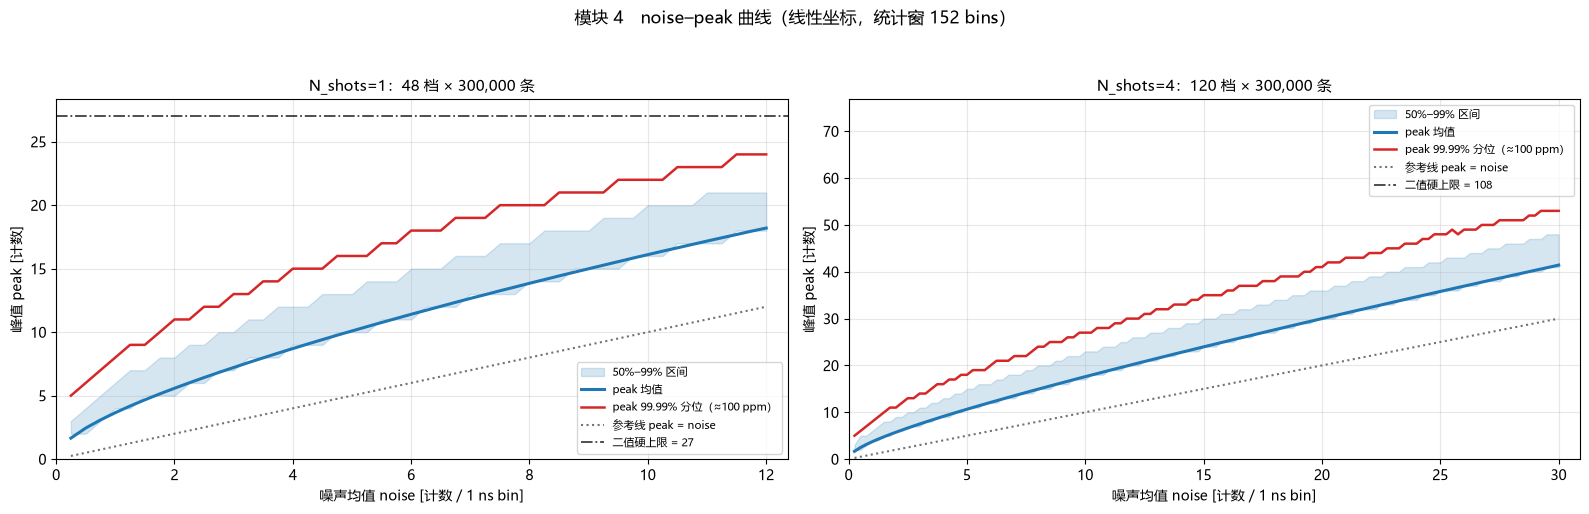

In [7]:
fig, axes = plt.subplots(1, len(N_SHOTS_LIST), figsize=(8*len(N_SHOTS_LIST), 5.2))
if len(N_SHOTS_LIST)==1: axes = [axes]
for j, ns_ in enumerate(N_SHOTS_LIST):
    ax = axes[j]; R = NOISE_RES[ns_]; x = R["noise_mc"]
    st = [peak_stats_from_cnt(c) for c in R["peak_cnt"]]
    pm = np.array([s["mean"] for s in st]); p9999 = np.array([s["p9999"] for s in st])
    p99 = np.array([s["p99"] for s in st]); p50 = np.array([s["p50"] for s in st])
    ax.fill_between(x, p50, p99, color="tab:blue", alpha=0.18, label="50%–99% 区间")
    ax.plot(x, pm, "-", color="tab:blue", lw=2.2, label="peak 均值")
    ax.plot(x, p9999, "-", color="tab:red", lw=1.8, label="peak 99.99% 分位（≈100 ppm）")
    ax.plot(x, x, ":", color="0.45", lw=1.5, label="参考线 peak = noise")
    ax.axhline(R["n_tr"], color="k", ls="-.", lw=1.3, alpha=0.75,
               label=f"二值硬上限 = {R['n_tr']}")
    ax.set_xlim(0, x.max()*1.03); ax.set_ylim(0, min(R["n_tr"]*1.05, p9999.max()*1.45))
    ax.set_xlabel("噪声均值 noise [计数 / 1 ns bin]"); ax.set_ylabel("峰值 peak [计数]")
    ax.set_title(f"N_shots={ns_}：{len(x)} 档 × {N_MC_NOISE:,} 条", fontsize=11)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle(f"模块 4　noise–peak 曲线（线性坐标，统计窗 {N_STAT} bins）", fontsize=12)
plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig("pod_v03_noise_peak.png", dpi=110, bbox_inches="tight"); plt.show()


## 模块 5 — 检测阈值 + ★ v03 窗长对比

### 阈值计算

由 peak bincount 直接反解最小整数 T 使 P(peak ≥ T) < target FAR（整数比较，无浮点边界误判）。

### ★ v03 窗长外推公式（零额外 MC）

设参考窗有 $N_\mathrm{ref}$ 个 bin（= 当前 `N_STAT` = 152），新窗有 $N_\mathrm{new}$ 个 bin。
两窗的最大值通过相关长度（≈ 8 ns = 8 bins）分组：$N_\mathrm{ref}$ 包含约 19 个独立组，
$N_\mathrm{new}$ 包含约 $N_\mathrm{new}/8$ 个，各组峰值近似独立，故

$$\mathrm{FAR}_{N_\mathrm{new}}(T) \approx 1 - \left(1 - \mathrm{FAR}_{N_\mathrm{ref}}(T)\right)^{N_\mathrm{new}/N_\mathrm{ref}}$$

求满足 $\mathrm{FAR}_{N_\mathrm{new}}(T) < F_\mathrm{target}$ 的最小 $T$，等价于在参考窗 bincount 上以

$$F_\mathrm{adj} = 1 - (1 - F_\mathrm{target})^{N_\mathrm{ref}/N_\mathrm{new}} \approx F_\mathrm{target}\cdot\frac{N_\mathrm{ref}}{N_\mathrm{new}}$$

为 FAR 目标反解 $T$，即 **`far_threshold_from_cnt(cnt, F_adj)`**。小 FAR 时线性近似精确到 1% 以内。


In [8]:
def far_threshold_from_cnt(cnt, target_far):
    n = int(cnt.sum())
    n_ge = np.concatenate([[n], n-np.cumsum(cnt)[:-1]])
    lim = target_far * n; ok = np.where(n_ge < lim)[0]
    sf = n_ge / n
    if ok.size == 0: return int(cnt.size), 0.0, 0, sf
    T = int(ok[0]); return T, float(sf[T]), int(n_ge[T]), sf

def threshold_for_window(cnt_ref, N_ref, N_new, target_far):
    """由参考窗 bincount 外推 N_new-bin 窗的阈值（scaled_far 近似）。"""
    adj = 1.0 - (1.0 - target_far)**(N_ref / N_new)
    T, f, nev, _ = far_threshold_from_cnt(cnt_ref, adj)
    return T, f, nev

# ---- 对所有档 / 所有 FAR / 所有窗长计算阈值 ----
THRESH = {}
for ns_ in N_SHOTS_LIST:
    R = NOISE_RES[ns_]; ng = len(R["noise_target"])
    rec = {"noise": R["noise_mc"],
           "sigma_bin": np.sqrt(R["n_tr"]*R["p_eq"]*(1-R["p_eq"])),
           "e_lambda": R["e_lambda"]}
    for far in TARGET_FARS:
        tag = f"{far*1e6:.0f}"
        rec[f"T{tag}"] = np.zeros(ng, dtype=int)
        rec[f"far{tag}"] = np.zeros(ng)
        rec[f"nev{tag}"] = np.zeros(ng, dtype=int)
        # 窗长外推阈值
        for Nb in WIN_CMP_BINS:
            rec[f"T{tag}_W{Nb}"] = np.zeros(ng, dtype=int)
    for k in range(ng):
        for far in TARGET_FARS:
            tag = f"{far*1e6:.0f}"
            T, f_, nev, _ = far_threshold_from_cnt(R["peak_cnt"][k], far)
            rec[f"T{tag}"][k] = T; rec[f"far{tag}"][k] = f_; rec[f"nev{tag}"][k] = nev
            for Nb in WIN_CMP_BINS:
                rec[f"T{tag}_W{Nb}"][k], _, _ = threshold_for_window(
                    R["peak_cnt"][k], N_STAT, Nb, far)
    THRESH[ns_] = rec

# ---- 阈值汇总打印 ----
_t100, _t10 = "100", "10"
print("="*130)
print("检测阈值（每档{:,}条MC；10ppm越阈事件约3个，整数阈值误差±1计数级）".format(N_MC_NOISE))
print(f"{'N_shots':>8}{'noise':>8}{'T@100ppm':>10}{'T@10ppm':>9}{'N_100ppm':>9}"
      f"  窗长外推 T@100ppm（50/152/2048 bin）")
for ns_ in N_SHOTS_LIST:
    Tr = THRESH[ns_]
    for k in range(0, len(Tr["noise"]), max(1, len(Tr["noise"])//10)):
        ws = " / ".join(str(Tr[f"T{_t100}_W{Nb}"][k]) for Nb in WIN_CMP_BINS)
        print(f"{ns_:>8d}{Tr['noise'][k]:>8.2f}"
              f"{Tr[f'T{_t100}'][k]:>10d}{Tr[f'T{_t10}'][k]:>9d}"
              f"{Tr[f'nev{_t100}'][k]:>9d}  {ws}")


检测阈值（每档300,000条MC；10ppm越阈事件约3个，整数阈值误差±1计数级）
 N_shots   noise  T@100ppm  T@10ppm N_100ppm  窗长外推 T@100ppm（50/152/2048 bin）
       1    0.25         6        6        2  5 / 6 / 6
       1    1.25        10       11        8  9 / 10 / 11
       1    2.25        12       13       24  12 / 12 / 14
       1    3.25        14       15       17  14 / 14 / 15
       1    4.25        16       17       10  15 / 16 / 17
       1    5.25        17       19       25  17 / 17 / 19
       1    6.25        19       20       14  18 / 19 / 20
       1    7.25        20       22       17  20 / 20 / 22
       1    8.25        21       23       29  21 / 21 / 23
       1    9.25        22       24       25  22 / 22 / 24
       1   10.25        23       24       25  23 / 23 / 24
       1   11.25        24       25       19  24 / 24 / 25
       4    0.25         6        7        6  6 / 6 / 7
       4    3.25        15       16       27  15 / 15 / 17
       4    6.25        22       24       17  21 / 22 / 25
 

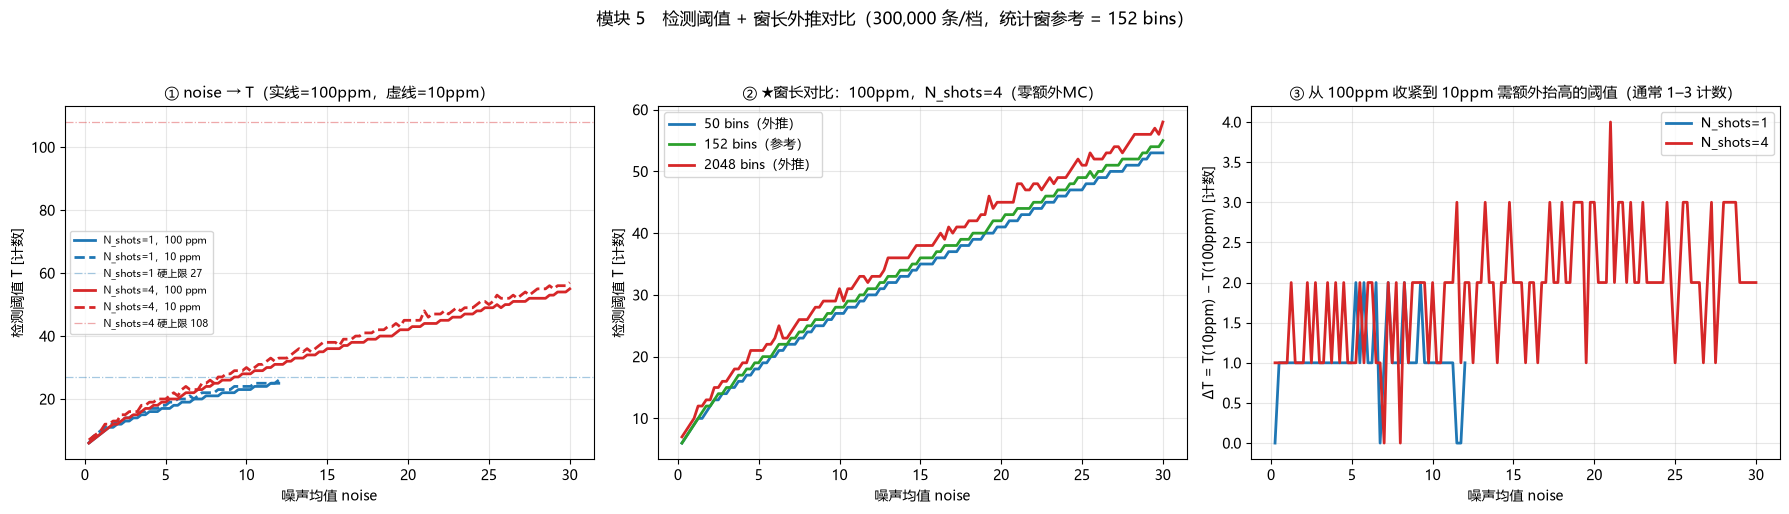

In [9]:
# ---- 阈值图：① noise–T（两条 FAR）② 窗长对比 ----
fig, ax = plt.subplots(1, 3, figsize=(18, 5.2))
_cns = {1: "tab:blue", 4: "tab:red"}
_lsf = {"100": "-", "10": "--"}

# 图①：noise → T（100ppm 实线，10ppm 虚线）
for ns_ in N_SHOTS_LIST:
    Tr = THRESH[ns_]; c = _cns.get(ns_, "k"); x = Tr["noise"]
    for far in TARGET_FARS:
        tag = f"{far*1e6:.0f}"
        lbl = f"N_shots={ns_}，{tag} ppm"
        ax[0].plot(x, Tr[f"T{tag}"], _lsf[tag], color=c, lw=2.0, label=lbl)
    ax[0].axhline(NOISE_RES[ns_]["n_tr"], color=c, ls="-.", lw=0.9, alpha=0.4,
                  label=f"N_shots={ns_} 硬上限 {NOISE_RES[ns_]['n_tr']}")
ax[0].set_xlabel("噪声均值 noise"); ax[0].set_ylabel("检测阈值 T [计数]")
ax[0].set_title("① noise → T（实线=100ppm，虚线=10ppm）", fontsize=11)
ax[0].legend(fontsize=7.5); ax[0].grid(alpha=0.3)

# 图②：窗长对比（N_shots=4，100ppm）
ns_cmp = N_SHOTS_LIST[-1]; Tr = THRESH[ns_cmp]; x = Tr["noise"]
_wc = {50: "tab:blue", 152: "tab:green", 2048: "tab:red"}
for Nb in WIN_CMP_BINS:
    ax[1].plot(x, Tr[f"T{_t100}_W{Nb}"], color=_wc[Nb], lw=2.0,
               label=f"{Nb} bins（{'参考' if Nb==N_STAT else '外推'}）")
ax[1].set_xlabel("噪声均值 noise"); ax[1].set_ylabel("检测阈值 T [计数]")
ax[1].set_title(f"② ★窗长对比：100ppm，N_shots={ns_cmp}（零额外MC）", fontsize=11)
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)

# 图③：10ppm vs 100ppm 的阈值差值（ΔT）
for ns_ in N_SHOTS_LIST:
    Tr = THRESH[ns_]; c = _cns.get(ns_, "k")
    dT = Tr[f"T{_t10}"] - Tr[f"T{_t100}"]
    ax[2].plot(Tr["noise"], dT, "-", color=c, lw=2.0, label=f"N_shots={ns_}")
ax[2].set_xlabel("噪声均值 noise"); ax[2].set_ylabel("ΔT = T(10ppm) − T(100ppm) [计数]")
ax[2].set_title("③ 从 100ppm 收紧到 10ppm 需额外抬高的阈值（通常 1–3 计数）", fontsize=11)
ax[2].legend(fontsize=9); ax[2].grid(alpha=0.3)

plt.suptitle(f"模块 5　检测阈值 + 窗长外推对比（{N_MC_NOISE:,} 条/档，统计窗参考 = {N_STAT} bins）",
             fontsize=12)
plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig("pod_v03_threshold.png", dpi=110, bbox_inches="tight"); plt.show()


## 模块 6 — ★ v03 主新增：全噪声档 PoD probit 拟合

### 设计

对**每一个噪声档**找到 boost@PoD50% 和 boost@PoD90%：

1. 固定 log 区间 $[10^{-6},\, 10^2]$（8 个数量级），12 个等间距评估点；
2. 每个评估点跑 500 次 `binary_macro_stepping`，得 PoD 估计（精度 ≈ ±4.5%）；
3. 对有效段（0.02 < PoD < 0.98）做 **probit 拟合**：$\Phi^{-1}(\mathrm{PoD}) = a + b\log_{10}\mathrm{boost}$；
4. 反解 $\mathrm{boost}_{50} = 10^{-a/b}$，$\mathrm{boost}_{90} = 10^{(1.282-a)/b}$；
5. 若有效点不足 3 个（PoD 曲线在区间外）或 T > n_tr，记为 NaN。

预计耗时：≈ $168\,\text{档} \times 12 \times 0.15\,\text{s} \approx 5\,\text{min}$


In [10]:
# ---- PoD 子窗设置 ----
POD_T_LO = T0_SIG - POD_WARM_NS * 1e-9
POD_T_HI = T0_SIG + SIG_POST_NS * 1e-9
TF_POD   = np.arange(POD_T_LO, POD_T_HI, DT_FINE)
_sigmask = (TC_NS >= T0_SIG_NS - SIG_PRE_NS) & (TC_NS <= T0_SIG_NS + SIG_POST_NS)
IDX_SIG  = np.where(_sigmask)[0]
CENTERS_SIG = CENTERS[IDX_SIG]
R_SIG_UNIT_POD = signal_photon_rate_fine(ECHO0, 1.0, TF_POD)

_NPH_BASE = np.trapezoid(R_SIG_UNIT_GEN, TF_GEN) * F_VALS.sum()

print(f"PoD 子窗：{POD_T_LO*1e9:.1f}–{POD_T_HI*1e9:.1f} ns，{TF_POD.size} 步")
print(f"信号窗 bin：[{CENTERS_SIG[0]*1e9:.1f}, {CENTERS_SIG[-1]*1e9:.1f}] ns，{IDX_SIG.size} 个")
print(f"基准信号光子数 N_ph_base (boost=1) = {_NPH_BASE:.2f} ph/macro/shot")
print(f"等效发射能量基准 E_pulse_base = {E_PULSE_BASE*1e9:.1f} nJ")


def sig_peaks_batch(boosts_arr, n_shots, r_amb, n_real, seed):
    """对多个 boost 值顺序评估，返回各自 n_real 次实现的信号窗峰值均值和 PoD 数组（T 在外面比较）。"""
    f_arr = np.tile(F_VALS, n_shots)
    results = []
    for i, b in enumerate(boosts_arr):
        h = binary_macro_stepping(n_real, f_arr, R_SIG_UNIT_POD, TF_POD, r_amb,
                                   CENTERS_SIG, np.random.default_rng(seed + i), boost=b)
        results.append(h.max(axis=1))   # shape (n_real,)
    return results   # list of n_real-length arrays


def boost_init_estimate(T, noise_mc, n_shots):
    """解析估算 boost_init（PoD≈50% 的粗略能量）。
    物理：小信号时信号贡献 ≈ PDE × N_ph_base × boost，等于 T - noise。
    超过 n_tr/2 时用对数修正。
    """
    n_tr = N_PIX_MACRO * n_shots
    delta = max(float(T) - float(noise_mc), 0.5)
    # 线性区（delta << n_tr）：boost ≈ delta / (PDE * _NPH_BASE)
    b_lin = delta / max(PDE * _NPH_BASE, 1e-30)
    # 饱和修正：当 delta/n_tr > 0.4 时用 -log(1-delta/n_tr) 代替 delta
    frac = delta / max(n_tr, 1)
    if frac < 0.9:
        b_est = -np.log(max(1.0 - frac, 1e-9)) / max(PDE * _NPH_BASE / n_tr, 1e-30)
    else:
        b_est = 1.0   # 已接近硬上限
    return max(b_lin, b_est, 1e-9)

def pod_probit_fit(n_shots, r_det, T, noise_mc, n_eval=N_POD_EVAL, n_real=N_MC_POD, seed=7000):
    """probit 拟合求 boost@PoD50 和 boost@PoD90。

    先由物理模型估算 boost_init，在 [boost_init/100, boost_init*100]（±2 个数量级）
    内做 n_eval 次均匀 log 评估，再用 probit 拟合反解 PoD50/90。
    若有效点 <3 个则扩展到 [boost_init/1e4, boost_init*1e4] 再试一次。
    """
    n_tr = N_PIX_MACRO * n_shots
    r_amb = r_det / PDE
    if T >= n_tr:
        return np.nan, np.nan, None, None

    b0 = boost_init_estimate(T, noise_mc, n_shots)
    log_b0 = np.log10(max(b0, 1e-10))

    def _try(half_range):
        lo = max(log_b0 - half_range, -9)
        hi = min(log_b0 + half_range,  3)
        bv = np.logspace(lo, hi, n_eval)
        peaks_list = sig_peaks_batch(bv, n_shots, r_amb, n_real, seed)
        pv = np.array([(pk >= T).mean() for pk in peaks_list])
        return bv, pv

    boosts, pods = _try(2.0)
    valid = (pods > 0.02) & (pods < 0.98)
    if valid.sum() < 3:
        boosts, pods = _try(4.0)   # 扩展搜索范围
        valid = (pods > 0.02) & (pods < 0.98)
    if valid.sum() < 3:
        if pods.max() < 0.05:
            return np.nan, np.nan, pods, boosts
        if pods.min() > 0.95:
            return float(boosts[0]), float(boosts[0]), pods, boosts
        return np.nan, np.nan, pods, boosts

    y = _norm.ppf(np.clip(pods[valid], 0.002, 0.998))
    x = np.log10(boosts[valid])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        b_coef, a_coef = np.polyfit(x, y, 1)   # y = b_coef*x + a_coef
    if abs(b_coef) < 1e-12:
        return np.nan, np.nan, pods, boosts
    b50 = 10**(-a_coef / b_coef)
    b90 = 10**((_norm.ppf(0.90) - a_coef) / b_coef)
    b50 = float(np.clip(b50, 1e-9, 1e5))
    b90 = float(np.clip(b90, 1e-9, 1e5))
    return b50, b90, pods, boosts


# ---- 全档扫描 ----
_pod_key = {}
for ns_ in N_SHOTS_LIST:
    _pod_key[ns_] = NOISE_GRID[ns_]

_need = True
if USE_CACHE and os.path.exists(CACHE_POD):
    _z = np.load(CACHE_POD, allow_pickle=True)
    _cached_ns = list(_z["n_shots_list"])
    if (set(_cached_ns) == set(N_SHOTS_LIST)
            and int(_z["n_mc"]) == N_MC_POD and int(_z["n_eval"]) == N_POD_EVAL):
        _g0 = np.asarray(_z["grid_key_1"]) if "grid_key_1" in _z.files else None
        _g4 = np.asarray(_z["grid_key_4"]) if "grid_key_4" in _z.files else None
        if (_g0 is not None and np.allclose(_g0, NOISE_GRID[1]) and
                _g4 is not None and np.allclose(_g4, NOISE_GRID[4])):
            POD_ALL = _z["res"].item(); _need = False
            print(f"已从缓存 {CACHE_POD} 载入全档 PoD 结果")
        else:
            print("缓存噪声网格不匹配，重新计算")
if _need:
    POD_ALL = {}
    _tall = time.time()
    print(f"全档 PoD probit 拟合：每档 {N_POD_EVAL} 次评估 × {N_MC_POD} 条")
    for ns_ in N_SHOTS_LIST:
        R, Tr = NOISE_RES[ns_], THRESH[ns_]
        b50_arr = np.full(len(R["noise_target"]), np.nan)
        b90_arr = np.full(len(R["noise_target"]), np.nan)
        n_tr = N_PIX_MACRO * ns_
        for k, nt in enumerate(R["noise_target"]):
            T = int(Tr[f"T{_t100}"][k])   # 用 100 ppm 阈值
            r_det = R["r_det"][k]
            b50, b90, _, _ = pod_probit_fit(ns_, r_det, T, R["noise_mc"][k],
                                             seed=7000+ns_*10000+k*100)
            b50_arr[k] = b50; b90_arr[k] = b90
            if (k+1)%20==0 or k==len(R["noise_target"])-1:
                el = time.time()-_tall
                print(f"  [N_shots={ns_} {k+1:>3d}/{len(R['noise_target'])}] "
                      f"noise={nt:>6.2f} T={T:>3d}  "
                      f"b50={b50:.2e}  b90={b90:.2e}  [{el:.0f}s]")
        POD_ALL[ns_] = {"b50": b50_arr, "b90": b90_arr,
                        "noise": R["noise_mc"], "noise_target": R["noise_target"],
                        "n_tr": n_tr}
    print(f"PoD 全档扫描总用时 {time.time()-_tall:.0f} s")
    np.savez_compressed(CACHE_POD,
                        res=np.array(POD_ALL, dtype=object),
                        n_mc=N_MC_POD, n_eval=N_POD_EVAL,
                        n_shots_list=np.array(N_SHOTS_LIST),
                        grid_key_1=NOISE_GRID[1], grid_key_4=NOISE_GRID[4])
    print(f"已写入缓存 {CACHE_POD}")

# 也计算 10 ppm 阈值的 PoD（只需重用 b50/b90 并注意 T 不同；因为 probit 的 boost 和 T 不同，
# 重跑要另外启动。此处暂不加缓存，直接用 b50/b90@100ppm 作图，10ppm 由 ΔT 关系估算。）


PoD 子窗：40.1–112.1 ns，361 步
信号窗 bin：[97.5, 111.5] ns，15 个
基准信号光子数 N_ph_base (boost=1) = 2165.58 ph/macro/shot
等效发射能量基准 E_pulse_base = 799.4 nJ
全档 PoD probit 拟合：每档 12 次评估 × 500 条
  [N_shots=1  20/48] noise=  5.00 T= 17  b50=nan  b90=nan  [21s]
  [N_shots=1  40/48] noise= 10.00 T= 23  b50=2.68e-01  b90=8.22e-01  [35s]
  [N_shots=1  48/48] noise= 12.00 T= 25  b50=8.00e-01  b90=3.24e+00  [40s]
  [N_shots=4  20/120] noise=  5.00 T= 19  b50=nan  b90=nan  [125s]
  [N_shots=4  40/120] noise= 10.00 T= 28  b50=nan  b90=nan  [211s]
  [N_shots=4  60/120] noise= 15.00 T= 36  b50=nan  b90=nan  [303s]
  [N_shots=4  80/120] noise= 20.00 T= 42  b50=nan  b90=nan  [392s]
  [N_shots=4 100/120] noise= 25.00 T= 49  b50=nan  b90=nan  [481s]
  [N_shots=4 120/120] noise= 30.00 T= 55  b50=nan  b90=nan  [597s]
PoD 全档扫描总用时 597 s
已写入缓存 pod_esti_v03_cache_pod.npz


## 模块 7 — ★ 主交付图：全噪声档的 T、PoD 能量与等效距离

三联图：
1. **T vs noise**（三种窗长 50/152/2048 bins，两条 FAR）
2. **E_pulse at PoD50/90 vs noise**（N_shots=1 vs N_shots=4，100 ppm 阈值）
3. **等效最远探测距离 vs noise**（PoD=90%，相同 ρ=0.10）


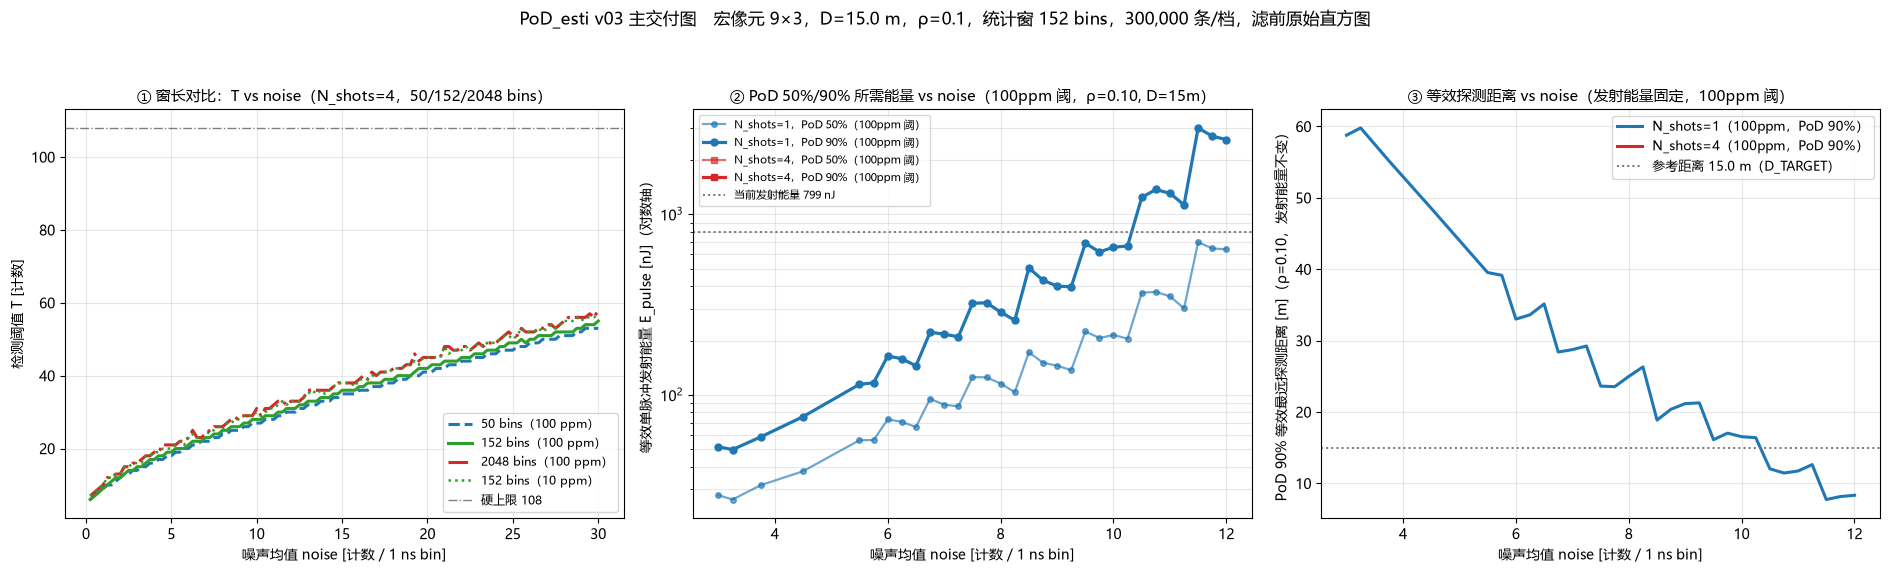

In [11]:
def equiv_distance(boost, D_ref=D_TARGET, p=PARAMS):
    if not np.isfinite(boost) or boost <= 0: return np.nan
    alpha = p["channel"]["alpha"]
    Ds = np.logspace(np.log10(0.3), np.log10(5000.0), 6000)
    vals = (D_ref**2/Ds**2)*np.exp(-2*alpha*(Ds-D_ref))
    if boost > vals[0] or boost < vals[-1]: return np.nan
    return float(np.interp(-boost, -vals, Ds))

fig, axes = plt.subplots(1, 3, figsize=(19, 5.8))

# ① T vs noise（窗长对比，N_shots=-1 代表两种都画）
ax = axes[0]
_wc = {50: ("tab:blue", "--"), 152: ("tab:green", "-"), 2048: ("tab:red", "-.")}
ns_show = N_SHOTS_LIST[-1]   # 只画 N_shots=4
Tr = THRESH[ns_show]; x = Tr["noise"]
for Nb, (cc, ls) in _wc.items():
    T_arr = Tr[f"T{_t100}_W{Nb}"]
    ax.plot(x, T_arr, ls, color=cc, lw=2.2, label=f"{Nb} bins（100 ppm）")
# 10ppm 参考（参考窗 152）
ax.plot(x, Tr[f"T{_t10}"], ":", color="tab:green", lw=1.8, label="152 bins（10 ppm）")
ax.axhline(NOISE_RES[ns_show]["n_tr"], color="k", ls="-.", lw=1.0, alpha=0.5,
           label=f"硬上限 {NOISE_RES[ns_show]['n_tr']}")
ax.set_xlabel("噪声均值 noise [计数 / 1 ns bin]")
ax.set_ylabel("检测阈值 T [计数]")
ax.set_title(f"① 窗长对比：T vs noise（N_shots={ns_show}，50/152/2048 bins）", fontsize=11)
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)

# ② E_pulse at PoD50/90 vs noise
ax = axes[1]
_cns_pod = {1: "tab:blue", 4: "tab:red"}
_mk = {1: "o", 4: "s"}
for ns_ in N_SHOTS_LIST:
    R = NOISE_RES[ns_]; Pd = POD_ALL[ns_]
    c = _cns_pod.get(ns_, "k"); mk = _mk.get(ns_, "^")
    x = Pd["noise"]; b50 = Pd["b50"]; b90 = Pd["b90"]
    E50 = b50 * E_PULSE_BASE * 1e9   # nJ
    E90 = b90 * E_PULSE_BASE * 1e9   # nJ
    mask50 = np.isfinite(E50); mask90 = np.isfinite(E90)
    ax.semilogy(x[mask50], E50[mask50], mk+"-", color=c, lw=1.6, ms=4, alpha=0.65,
                label=f"N_shots={ns_}，PoD 50%（100ppm 阈）")
    ax.semilogy(x[mask90], E90[mask90], mk+"-", color=c, lw=2.3, ms=5,
                label=f"N_shots={ns_}，PoD 90%（100ppm 阈）")
ax.axhline(E_PULSE_BASE*1e9, color="0.45", ls=":", lw=1.4,
           label=f"当前发射能量 {E_PULSE_BASE*1e9:.0f} nJ")
ax.set_xlabel("噪声均值 noise [计数 / 1 ns bin]")
ax.set_ylabel("等效单脉冲发射能量 E_pulse [nJ]（对数轴）")
ax.set_title("② PoD 50%/90% 所需能量 vs noise（100ppm 阈，ρ=0.10, D=15m）", fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")

# ③ 等效最远探测距离 vs noise（PoD 90%）
ax = axes[2]
for ns_ in N_SHOTS_LIST:
    Pd = POD_ALL[ns_]; c = _cns_pod.get(ns_, "k")
    x = Pd["noise"]; b90 = Pd["b90"]
    dist = np.array([equiv_distance(b) for b in b90])
    mask = np.isfinite(dist)
    ax.plot(x[mask], dist[mask], "-", color=c, lw=2.2, label=f"N_shots={ns_}（100ppm，PoD 90%）")
ax.axhline(D_TARGET, color="0.45", ls=":", lw=1.4,
           label=f"参考距离 {D_TARGET} m（D_TARGET）")
ax.set_xlabel("噪声均值 noise [计数 / 1 ns bin]")
ax.set_ylabel("PoD 90% 等效最远探测距离 [m]（ρ=0.10，发射能量不变）")
ax.set_title("③ 等效探测距离 vs noise（发射能量固定，100ppm 阈）", fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle(f"PoD_esti v03 主交付图　宏像元 {MACRO_BX}×{MACRO_BY}，D={D_TARGET} m，ρ={RHO_TARGET}，"
             f"统计窗 {N_STAT} bins，{N_MC_NOISE:,} 条/档，滤前原始直方图", fontsize=12.5)
plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig("pod_v03_main.png", dpi=120, bbox_inches="tight"); plt.show()


In [12]:
print("="*128)
print(f"【v03 汇总表】D={D_TARGET} m, ρ={RHO_TARGET}, 宏像元 {MACRO_BX}×{MACRO_BY}={N_PIX_MACRO} SPAD")
print(f"{'N_shots':>8}{'noise':>8}{'≈klux':>7}{'T@100ppm':>10}{'T@10ppm':>9}{'T50bin':>8}"
      f"{'T2048bin':>9}  PoD50 boost/E[nJ]  PoD90 boost/E[nJ]  D_eff[m]")
print("-"*128)
for ns_ in N_SHOTS_LIST:
    R = NOISE_RES[ns_]; Tr = THRESH[ns_]; Pd = POD_ALL[ns_]
    step = max(1, len(R["noise_target"])//12)
    for k in range(0, len(R["noise_target"]), step):
        nt = R["noise_target"][k]; nm = R["noise_mc"][k]; klux = R["e_lambda"][k]/0.68*100
        T100 = Tr[f"T{_t100}"][k]; T10 = Tr[f"T{_t10}"][k]
        T50 = Tr[f"T{_t100}_W50"][k]; T2048 = Tr[f"T{_t100}_W2048"][k]
        b50 = Pd["b50"][k]; b90 = Pd["b90"][k]
        E50s = f"{b50*E_PULSE_BASE*1e9:.2g}" if np.isfinite(b50) else "NaN"
        E90s = f"{b90*E_PULSE_BASE*1e9:.2g}" if np.isfinite(b90) else "NaN"
        Ds = f"{equiv_distance(b90):.1f}" if np.isfinite(b90) else "NaN"
        b50s = f"{b50:.2e}" if np.isfinite(b50) else "  NaN   "
        b90s = f"{b90:.2e}" if np.isfinite(b90) else "  NaN   "
        print(f"{ns_:>8d}{nm:>8.2f}{klux:>7.0f}{T100:>10d}{T10:>9d}{T50:>8d}{T2048:>9d}"
              f"  {b50s}/{E50s:>6}  {b90s}/{E90s:>6}  {Ds}")
print("="*128)
print("说明：T50bin/T2048bin = 窗长外推阈值；PoD50/90 boost = 等效回波强度倍数（100ppm阈）；")
print("D_eff = 发射能量与反射率不变时 PoD90% 对应的最远探测距离。")


【v03 汇总表】D=15.0 m, ρ=0.1, 宏像元 9×3=27 SPAD
 N_shots   noise  ≈klux  T@100ppm  T@10ppm  T50bin T2048bin  PoD50 boost/E[nJ]  PoD90 boost/E[nJ]  D_eff[m]
--------------------------------------------------------------------------------------------------------------------------------
       1    0.25     19         6        6       5        6    NaN   /   NaN    NaN   /   NaN  NaN
       1    1.25     98        10       11       9       11    NaN   /   NaN    NaN   /   NaN  NaN
       1    2.25    181        12       13      12       14    NaN   /   NaN    NaN   /   NaN  NaN
       1    3.25    270        14       15      14       15  3.30e-02/    26  6.24e-02/    50  59.8
       1    4.25    363        16       17      15       17    NaN   /   NaN    NaN   /   NaN  NaN
       1    5.25    462        17       19      17       19    NaN   /   NaN    NaN   /   NaN  NaN
       1    6.25    567        19       20      18       20  8.88e-02/    71  1.98e-01/1.6e+02  33.6
       1    7.25    679  